## Validation of PVade against DuraMAT experimental campaign ##

In [30]:
import pandas as pd
import numpy as np
import yaml
import pickle
import importlib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# spectra
from scipy.signal import welch
from numpy import hanning
import math

# from postprocessing_functions import *
# importlib.reload(postprocessing_functions) # to reload functions without restarting the notebook

In [31]:
pwd

'/kfs2/projects/pvopt/aps_dfd_2024/PVade/postprocessing'

In [32]:
# copying from https://github.com/brookeslawski/scripts/blob/main/pvade-pproc-aps2024.ipynb
parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
# casepath = 'y20m_turbinflow_duramat_validation/'

casepath = 'halfwing_turbinflow_duramat_validation_40deg/'
exp_data_fn = 'DuraMAT_tilt40deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_neg40deg/'
# exp_data_fn = 'DuraMAT_tiltneg40deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_-10.0deg/'
# exp_data_fn = 'DuraMAT_tiltneg10deg_turbulent_inflow_10min_timeseries.csv'

# casepath = 'halfwing_turbinflow_duramat_validation_10.0deg/'
# exp_data_fn = 'DuraMAT_tilt10deg_turbulent_inflow_10min_timeseries.csv'

tilts = [40.0]
# panel_span = 10.0
# panel_chord = 4.1

### Step 1: read in csv data (lift and drag, acceleration at NE corner of panel) ###

In [33]:
# read in lift and drag
output_dir=parentdir+'output/'+casepath
tmp = pd.read_csv(output_dir+'solution/lift_and_drag.csv')
tmp.rename(columns={'#Time': 'Time'}, inplace=True)
tmp = tmp.set_index('Time')
loadsdata = tmp

# read in accelerations
tmp2 = pd.read_csv(output_dir+'solution/accel_pos.csv')
#handling runs with updated outputs
if 'deformation' in tmp2.columns[0]:
    loadsdata['accel-x'] = tmp2['x-acceleration'].values
    loadsdata['accel-y'] = tmp2['y-acceleration'].values
    loadsdata['accel-z'] = tmp2['z-acceleration'].values
    loadsdata['accel-magnitude'] = loadsdata['accel-x']**2 + loadsdata['accel-y']**2 + loadsdata['accel-z']**2
else:
    loadsdata['accel-x'] = tmp2['#x-pos'].values
    loadsdata['accel-y'] = tmp2['y-pos'].values
    loadsdata['accel-z'] = tmp2['z-pos'].values
    loadsdata['accel-magnitude'] = loadsdata['accel-x']**2 + loadsdata['accel-y']**2 + loadsdata['accel-z']**2

# clean up
del tmp
del tmp2

loadsdata

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude
Time,,,,,,,,,,
0.006,113607.135200,132.696883,133550.370800,49.236320,0.057510,57.879541,0.000000,0.000000,0.000000,0.000000e+00
0.012,19873.502070,52.377070,20835.285660,8.612999,0.022700,9.029827,0.000401,-0.000116,0.000610,5.464996e-07
0.018,-793.586153,11.967077,-3605.998304,-0.343933,0.005186,-1.562808,0.003688,-0.000230,0.004461,3.355422e-05
0.024,4603.389574,-8.287656,4502.455164,1.995068,-0.003592,1.951324,0.012998,-0.000266,0.014655,3.837798e-04
0.030,7825.954612,-19.932090,8340.930204,3.391699,-0.008638,3.614885,0.025262,-0.000229,0.028054,1.425257e-03
...,...,...,...,...,...,...,...,...,...,...
29.772,3436.431985,16.250668,3790.268390,1.489319,0.007043,1.642669,-0.028406,-0.000155,-0.033469,1.927086e-03
29.778,3438.716175,16.697791,3792.615598,1.490309,0.007237,1.643686,-0.029770,-0.000167,-0.035025,2.113030e-03
29.784,3510.517102,15.760810,3866.847967,1.521427,0.006831,1.675857,-0.031197,-0.000179,-0.036644,2.316020e-03


### Step 2: Read in post-processed velocity data from PVade sim ###

In [34]:
# read input parameters
with open(output_dir+'input_params.yaml', 'r') as file:
    params = yaml.safe_load(file)

print('tracker_angle = {} m/s'.format(params['pv_array']['tracker_angle']))
dt_sim = params['solver']['dt']
dt_xdmf = params['solver']['save_xdmf_interval']
panel_span = params['pv_array']['panel_span']
panel_chord = params['pv_array']['panel_chord']
tf = params['solver']['t_final']

tracker_angle = 40.0 m/s


In [35]:
# read velocity data
readdata = {}
coords = {}
    
for j, tilt in enumerate(tilts):
    readdata[tilt] = {}
    coords[tilt] = {}

    pkl_fname = f'duramatval_tracker_angle_{tilt}.pkl'
    pkl_path = parentdir+'interp_data/timeseries_data/'+pkl_fname

    print('reading from', pkl_path)

    try:
        with open(pkl_path, 'rb') as f:
            # try:
            readrawdata = pickle.load(f)
                
            # print(rawdata[winddir][tilt][case].keys())
            readdata[tilt]['u'] = readrawdata['u']
            readdata[tilt]['v'] = readrawdata['v']
            readdata[tilt]['w'] = readrawdata['w']
            print('vel data nt, nx, ny, nz = ', np.shape(readdata[tilt]['u']))
    except Exception as e:
        print(f"Error loading pickle file: {e}")

# i think coords are only different for each tilt angle
if 'X' in readrawdata.keys():
    tmpX = readrawdata['X']
    print('coord nx, ny, nz = ', np.shape(tmpX))
    del tmpX

    coords[tilt]['X'] = readrawdata['X']
    coords[tilt]['Y'] = readrawdata['Y']
    coords[tilt]['Z'] = readrawdata['Z']
                        
del readrawdata

ndim = len(np.shape(readdata[tilt]['u']))

reading from /scratch/bstanisl/pvade/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_40.0.pkl
vel data nt, nx, ny, nz =  (2484, 131, 65, 50)
coord nx, ny, nz =  (131, 65, 50)


In [52]:
np.nanmean(readdata[tilt]['u'][:,0,j,k])

np.float64(9.016968331125952)

In [ ]:
# find best fit log law
target_wspds = [

In [36]:
# create dataframe from velocity data
nt = np.shape(readdata[tilt]['u'])[0]
time_xdmf = np.arange(dt_xdmf, tf+dt_xdmf, dt_xdmf)[0:nt] #np.linspace(dt_xdmf, tf, nt)

xi = coords[tilt]['X'][:,0,0]
yi = coords[tilt]['Y'][0,:,0]
zi = coords[tilt]['Z'][0,0,:]

# velocity signal at sonic location
# [xloc, yloc, zloc] = [-12.36, 0.0, 2.23]
[xloc, yloc, zloc] = [-12.36, 4.5, 2.23]
i = int(np.argmin(np.abs(xi - xloc)))
j = int(np.argmin(np.abs(yi - yloc)))
k = int(np.argmin(np.abs(zi - zloc)))
# print(f'sonic loc indices = {i, j, k}')

vel_data = pd.DataFrame(index=time_xdmf)
# for comp in ['u', 'v', 'w']:
#     vel_data[comp+' (m/s) at inlet'] = readdata[tilt][comp][:,0,j,k]
# for comp in ['u', 'v', 'w']:
#     vel_data[comp+' (m/s) at sonic'] = readdata[tilt][comp][:,i,j,k]
for comp in ['u', 'v', 'w']:
    vel_data[comp+' (m/s)'] = readdata[tilt][comp][:,0,j,k]
vel_data

,u (m/s),v (m/s),w (m/s)
0.012,NaN,NaN,NaN
0.024,NaN,NaN,NaN
0.036,NaN,NaN,NaN
0.048,NaN,NaN,NaN
0.060,NaN,NaN,NaN
...,...,...,...
29.760,12.280747,-0.587871,-1.765939
29.772,11.964950,0.198850,-1.075521
29.784,11.527256,0.422440,-0.793668
29.796,11.245832,0.501691,-0.735165


In [37]:
# merge sim data
sim_data = pd.merge(loadsdata, vel_data, left_index=True, right_index=True, how='inner')
sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude,u (m/s),v (m/s),w (m/s)
0.012,19873.502070,52.377070,20835.285660,8.612999,0.022700,9.029827,0.000401,-0.000116,0.000610,5.464996e-07,NaN,NaN,NaN
0.024,4603.389574,-8.287656,4502.455164,1.995068,-0.003592,1.951324,0.012998,-0.000266,0.014655,3.837798e-04,NaN,NaN,NaN
0.048,16310.913140,-55.034878,18893.307090,7.069004,-0.023852,8.188191,0.027315,-0.000019,0.031216,1.720544e-03,NaN,NaN,NaN
0.060,6548.667510,-22.863567,7252.295381,2.838134,-0.009909,3.143080,0.026296,-0.000023,0.028816,1.521825e-03,NaN,NaN,NaN
0.072,8389.988721,-11.025334,9778.997479,3.636146,-0.004778,4.238130,0.006012,0.000008,0.006094,7.328344e-05,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.724,3437.745271,8.594263,3792.267976,1.489888,0.003725,1.643535,-0.020041,-0.000079,-0.023777,9.669869e-04,12.859063,-0.162427,-1.164129
29.736,3542.082251,10.702913,3907.070476,1.535107,0.004639,1.693290,-0.021715,-0.000093,-0.025738,1.133995e-03,12.692189,-0.114914,-1.790215
29.748,3469.366151,10.834182,3825.836186,1.503592,0.004695,1.658083,-0.023631,-0.000111,-0.027975,1.341086e-03,12.602364,-0.925551,-2.104065
29.760,3509.547874,11.497798,3870.294198,1.521007,0.004983,1.677351,-0.025862,-0.000132,-0.030553,1.602348e-03,12.280747,-0.587871,-1.765939


In [38]:
# calculate lift and drag coeff
sfc_area = panel_span * panel_chord
sim_data['vel_mag (m/s)'] = (sim_data['u (m/s)']**2 + sim_data['v (m/s)']**2 + sim_data['w (m/s)']**2)**0.5
sim_data['fx_nd_calc'] = (sim_data['fx_0'])/(0.5*1*sim_data['vel_mag (m/s)']**2*sfc_area)
sim_data['fz_nd_calc'] = (sim_data['fz_0'])/(0.5*1*sim_data['vel_mag (m/s)']**2*sfc_area)

### Step 3: read in measurement data from DuraMAT ###

In [39]:
# read in experimental data
def read_csv_data(raw_data):
    # read csv
    exp_data = raw_data
    
    # construct time index
    tmp = (exp_data.index[1]-exp_data.index[0])
    dt_sonic1 = round(tmp.total_seconds(), 3)
    tf_sonic1 = len(exp_data) * dt_sonic1 # final time [s]
    t_sonic1 = np.arange(0.0, tf_sonic1, dt_sonic1)

    exp_data['u (m/s)'] = -1.0*exp_data['u (m/s)'] # to make it positive from the west
    exp_data['Time'] = t_sonic1
    exp_data = exp_data.set_index('Time')

    return tf_sonic1, exp_data
    
raw_exp_data = pd.read_csv(exp_data_fn, index_col='Time')
raw_exp_data.index = pd.to_datetime(raw_exp_data.index)

tf_sonic1, exp_data = read_csv_data(raw_exp_data)
dt_exp = exp_data.index[1]-exp_data.index[0]

# cut sonic data to time period simulated
if tilt == -40.0:
    tstart = 250.0
elif tilt == 40.0:
    tstart = 0.0
elif tilt == -10.0:
    tstart = 280.0
elif tilt == 10.0:
    tstart = 100.0

exp_data = exp_data[exp_data.index >= tstart]
exp_data = exp_data[exp_data.index <= sim_data.index[-1]+tstart]
exp_data.index = exp_data.index - tstart
exp_data = exp_data[exp_data.index > 0.0]

exp_data

,3D wind speed (m/s),Wind direction (deg),u (m/s),v (m/s),w (m/s),temp (degC),Drive tracker angle (deg),Drive torque north (kNm),Panel defl mid (mm),Drag force (kN),Lift force (kN),Drag force tracker angle (kN),Lift force tracker angle (kN),AccNW X (g),AccNW Y (g),AccNE X (g),AccNE Y (g)
Time,,,,,,,,,,,,,,,,,
0.02,9.567942,270.04828,9.540954,0.008039,0.718082,14.153996,40.541090,-2.579051,2.677513,4.023743,4.795310,4.068848,4.757097,-0.050700,0.036745,-1.161277,0.635432
0.04,9.567616,270.04276,9.540588,0.007120,0.718604,14.154172,40.541640,-2.544011,2.768883,3.969075,4.730159,4.013612,4.692427,-0.045759,0.042331,-0.465499,0.625758
0.06,9.568180,270.03586,9.541167,0.005969,0.718446,14.155300,40.545723,-2.507620,2.833717,3.912299,4.662497,3.956530,4.625022,-0.128438,-0.012178,-0.807424,0.672569
0.08,9.568017,270.03380,9.541007,0.005632,0.718398,14.154648,40.539486,-2.425076,2.631208,3.783517,4.509019,3.825804,4.473195,-0.133445,-0.025662,-0.659689,0.699951
0.10,9.568154,270.04370,9.541139,0.007275,0.718469,14.155776,40.544342,-2.312586,2.490352,3.608014,4.299863,3.648701,4.265391,0.303243,0.025229,-0.657600,0.629614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,12.780877,262.78656,12.590276,-1.593523,-1.515404,14.300554,40.462505,-2.074871,2.672827,3.237139,3.857871,3.268174,3.831615,0.004986,-0.020440,-0.731875,0.692967
29.72,12.780626,262.78550,12.590027,-1.593730,-1.515144,14.299802,40.463005,-2.063795,2.636113,3.219859,3.837278,3.250762,3.811134,0.197785,0.007008,-0.840510,0.660998
29.74,12.780664,262.77560,12.589726,-1.595900,-1.515681,14.300103,40.462837,-2.040101,2.448396,3.182892,3.793223,3.213430,3.767388,0.108501,0.000030,-1.018290,0.663273


In [40]:
# calculate lift and drag force coefficients
exp_data['Drag Coefficient'] = (exp_data['Drag force (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)
exp_data['Lift Coefficient'] = (exp_data['Lift force (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)

In [41]:
# interpolate to 50 Hz to match duramat loads signals
new_time_index = exp_data.index #exp_data[exp_data.index>0.0].index
interp_sim_data = pd.DataFrame(index=new_time_index)
for col in sim_data.columns:
    interpolator = interp1d(sim_data.index, sim_data[col].values, kind='linear')  # Use 'linear' or 'cubic' as needed
    interp_sim_data[col] = interpolator(new_time_index)

interp_sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude,u (m/s),v (m/s),w (m/s),vel_mag (m/s),fx_nd_calc,fz_nd_calc
Time,,,,,,,,,,,,,,,,
0.02,9693.427073,11.933919,9946.731996,4.201045,0.005172,4.310825,0.008799,-0.000216,0.009973,0.000256,NaN,NaN,NaN,NaN,NaN,NaN
0.04,12408.405285,-39.452470,14096.356448,5.377692,-0.017098,6.109235,0.022543,-0.000101,0.025695,0.001275,NaN,NaN,NaN,NaN,NaN,NaN
0.06,6548.667510,-22.863567,7252.295381,2.838134,-0.009909,3.143080,0.026296,-0.000023,0.028816,0.001522,NaN,NaN,NaN,NaN,NaN,NaN
0.08,10192.793387,-9.827707,11788.861660,4.417466,-0.004259,5.109188,-0.002723,0.000072,-0.004488,0.000122,NaN,NaN,NaN,NaN,NaN,NaN
0.10,5130.084485,10.322426,6049.820185,2.223333,0.004474,2.621938,-0.038194,0.000157,-0.043387,0.003500,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.70,3300.263615,4.627776,3641.739123,1.430305,0.002006,1.578297,-0.017333,-0.000060,-0.020598,0.000736,12.807362,-0.544100,-0.638059,12.839511,0.747092,0.824394
29.72,3404.586867,7.643134,3755.886974,1.475518,0.003312,1.627768,-0.019552,-0.000075,-0.023200,0.000922,12.855840,-0.291030,-0.922512,12.897976,0.763793,0.842605
29.74,3517.843551,10.746670,3879.992379,1.524602,0.004658,1.681554,-0.022354,-0.000099,-0.026484,0.001203,12.662247,-0.385126,-1.894832,12.815651,0.799398,0.881693


In [43]:
# merge dataframes
alldata = {}

alldata['exp'] = exp_data.copy()
alldata['sim'] = sim_data.copy()
alldata['sim_interp'] = interp_sim_data.copy()

# adjustments
alldata['exp'] = alldata['exp'].rename(columns={'3D wind speed (m/s)':'vel_mag (m/s)'})

for comp in ['fx','fy','fz']:
    alldata['sim'][comp+'_0'] = alldata['sim'][comp+'_0']/1000
    alldata['sim_interp'][comp+'_0'] = alldata['sim_interp'][comp+'_0']/1000

for key in ['sim','sim_interp']:
    alldata[key] = alldata[key].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)',
                                               'fx_nd_calc':'Drag Coefficient','fz_nd_calc':'Lift Coefficient', 
                                                'accel-x':'AccNE X (g)', 'accel-z':'AccNE Y (g)'})
    # alldata['sim'] = alldata['sim'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})
    # alldata['sim_interp'] = alldata['sim_interp'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})

alldata['sim']

,Drag force (kN),Lateral force (kN),Lift force (kN),fx_nd_0,fy_nd_0,fz_nd_0,AccNE X (g),accel-y,AccNE Y (g),accel-magnitude,u (m/s),v (m/s),w (m/s),vel_mag (m/s),Drag Coefficient,Lift Coefficient
0.012,19.873502,0.052377,20.835286,8.612999,0.022700,9.029827,0.000401,-0.000116,0.000610,5.464996e-07,NaN,NaN,NaN,NaN,NaN,NaN
0.024,4.603390,-0.008288,4.502455,1.995068,-0.003592,1.951324,0.012998,-0.000266,0.014655,3.837798e-04,NaN,NaN,NaN,NaN,NaN,NaN
0.048,16.310913,-0.055035,18.893307,7.069004,-0.023852,8.188191,0.027315,-0.000019,0.031216,1.720544e-03,NaN,NaN,NaN,NaN,NaN,NaN
0.060,6.548668,-0.022864,7.252295,2.838134,-0.009909,3.143080,0.026296,-0.000023,0.028816,1.521825e-03,NaN,NaN,NaN,NaN,NaN,NaN
0.072,8.389989,-0.011025,9.778997,3.636146,-0.004778,4.238130,0.006012,0.000008,0.006094,7.328344e-05,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.724,3.437745,0.008594,3.792268,1.489888,0.003725,1.643535,-0.020041,-0.000079,-0.023777,9.669869e-04,12.859063,-0.162427,-1.164129,12.912671,0.769506,0.848863
29.736,3.542082,0.010703,3.907070,1.535107,0.004639,1.693290,-0.021715,-0.000093,-0.025738,1.133995e-03,12.692189,-0.114914,-1.790215,12.818336,0.804574,0.887480
29.748,3.469366,0.010834,3.825836,1.503592,0.004695,1.658083,-0.023631,-0.000111,-0.027975,1.341086e-03,12.602364,-0.925551,-2.104065,12.810282,0.789048,0.870121
29.760,3.509548,0.011498,3.870294,1.521007,0.004983,1.677351,-0.025862,-0.000132,-0.030553,1.602348e-03,12.280747,-0.587871,-1.765939,12.420986,0.849004,0.936273


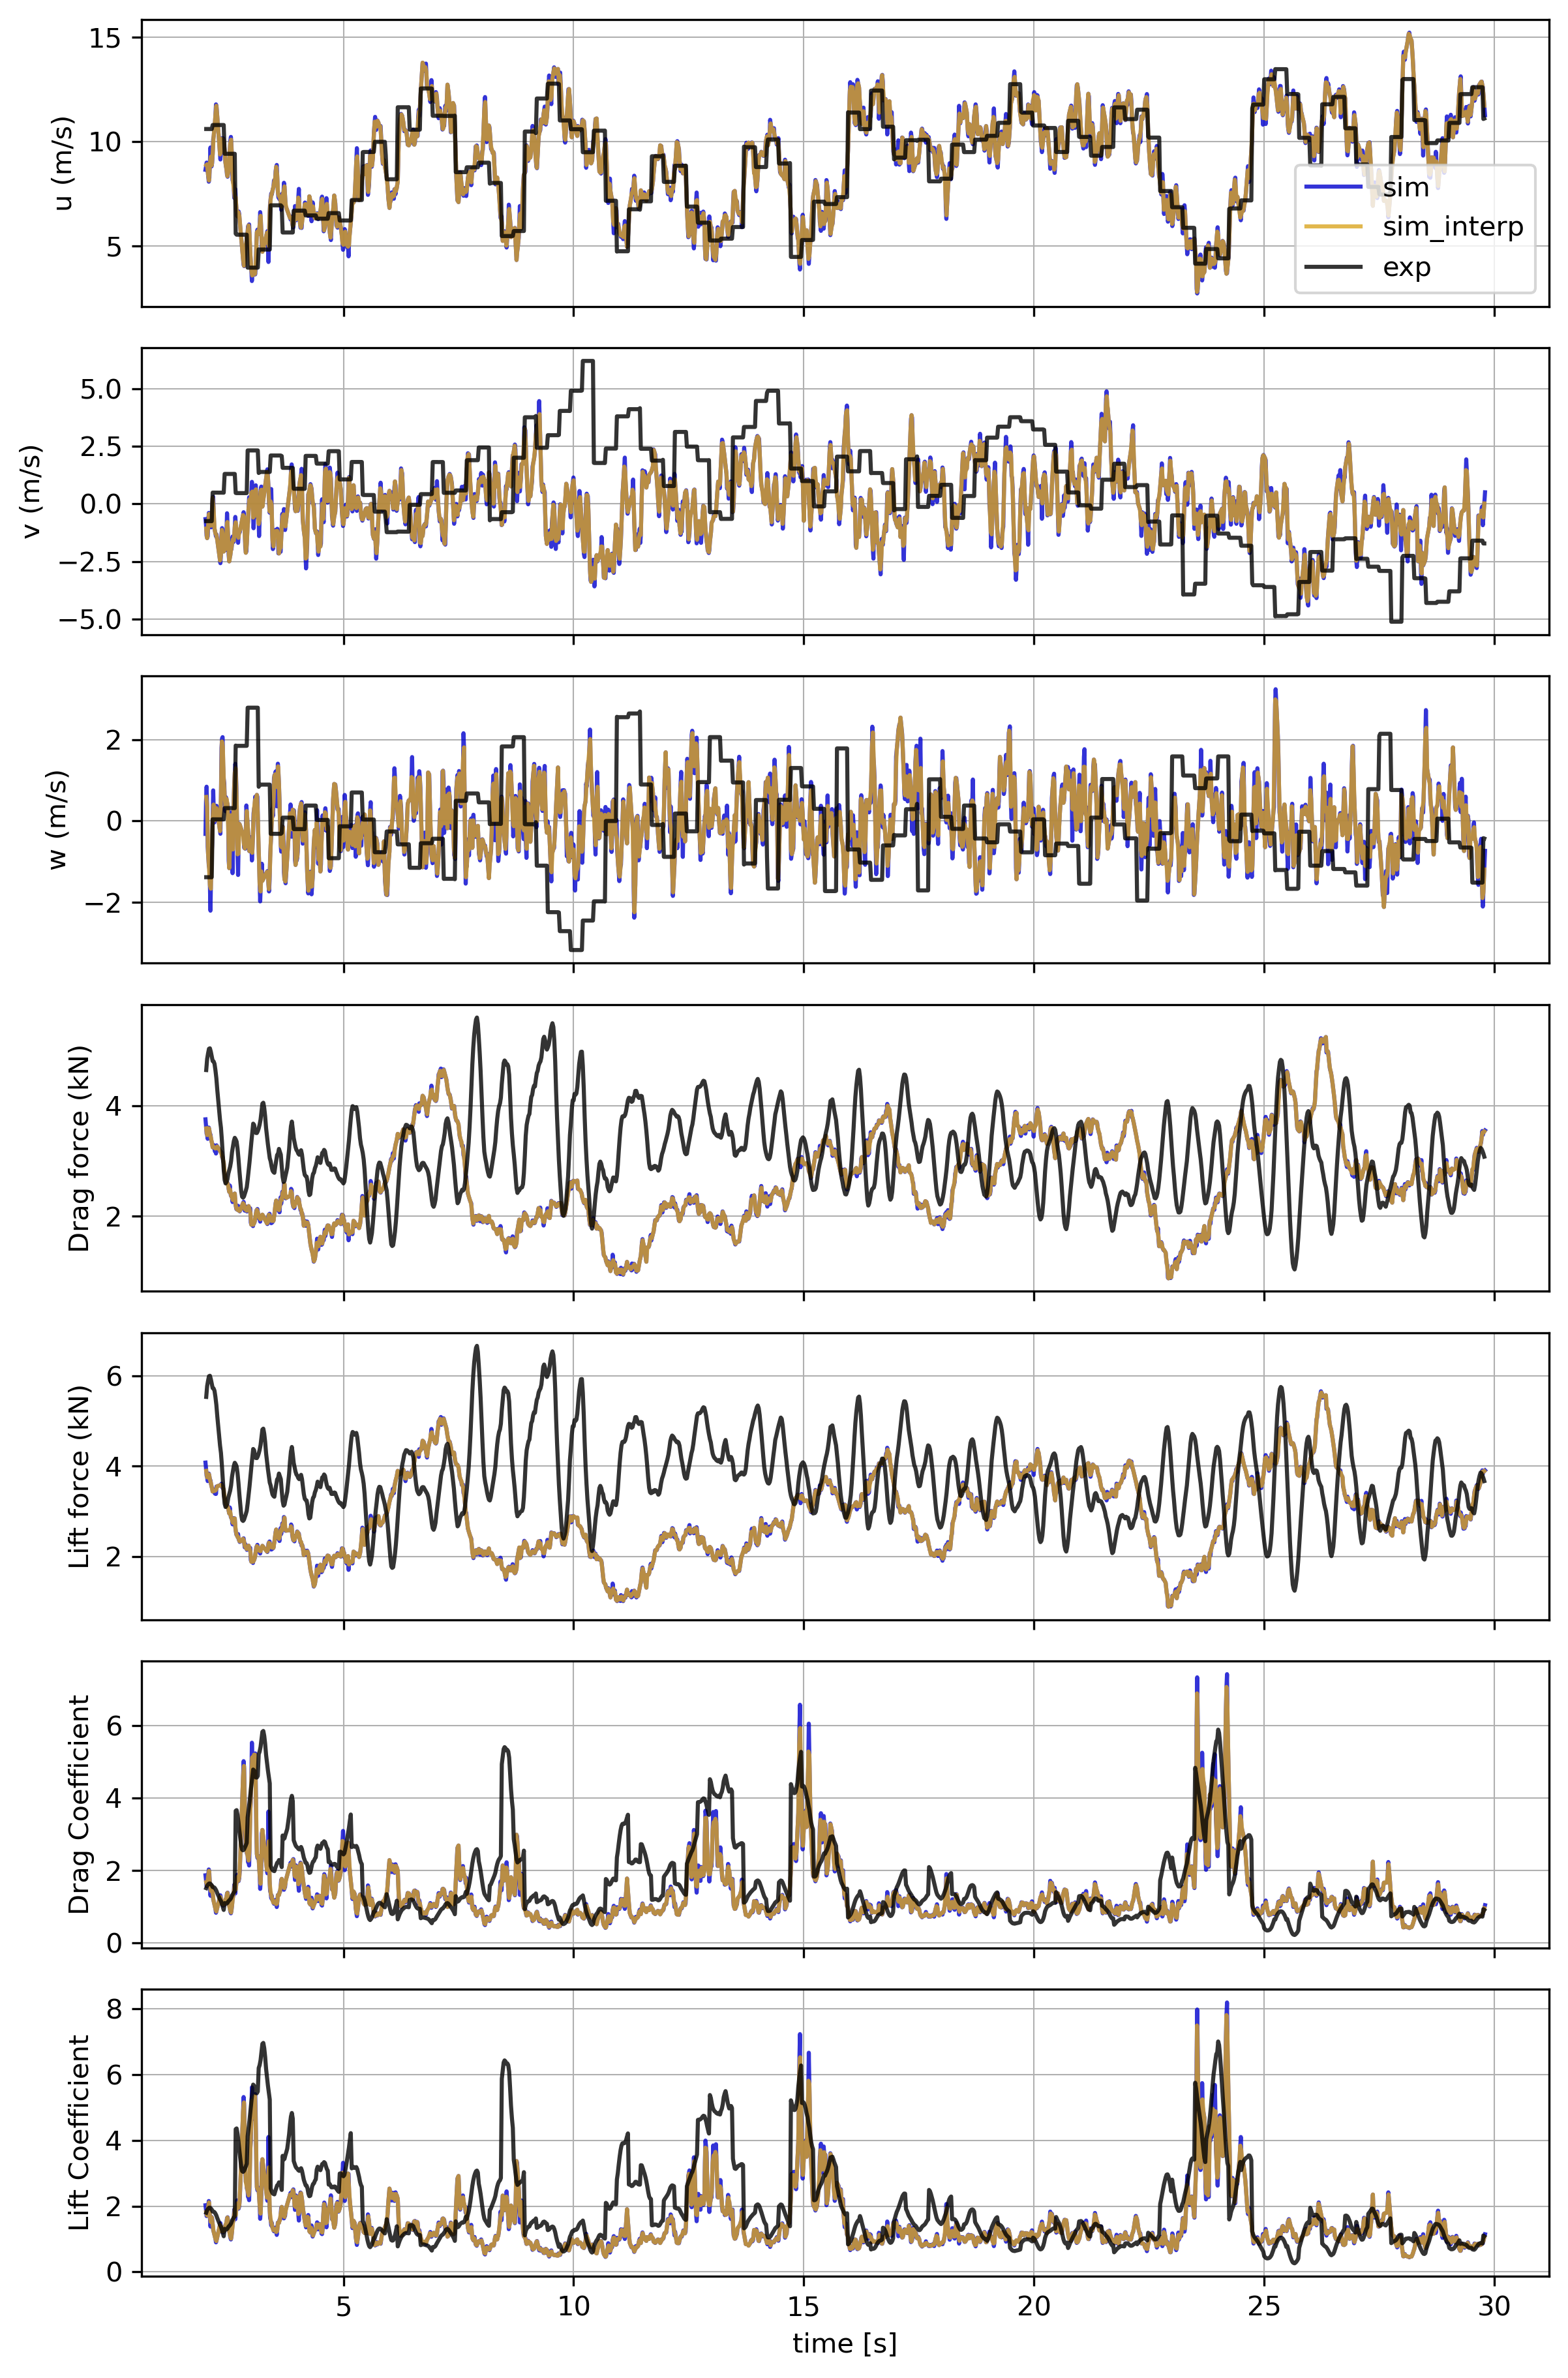

In [44]:
# plot velocity signals and drag and lift force
colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}

comps = ['u (m/s)','v (m/s)','w (m/s)','Drag force (kN)', 'Lift force (kN)','Drag Coefficient', 'Lift Coefficient']
vars = ['sim','sim_interp','exp']
# vars = ['exp']

fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)

for comp,ax in zip(comps, axs.ravel()):
    for var in vars:
        pltdata = alldata[var][comp][alldata[var][comp].index > 2.0]
        ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
axs[0].legend()
axs[-1].set_xlabel("time [s]")
plt.tight_layout()

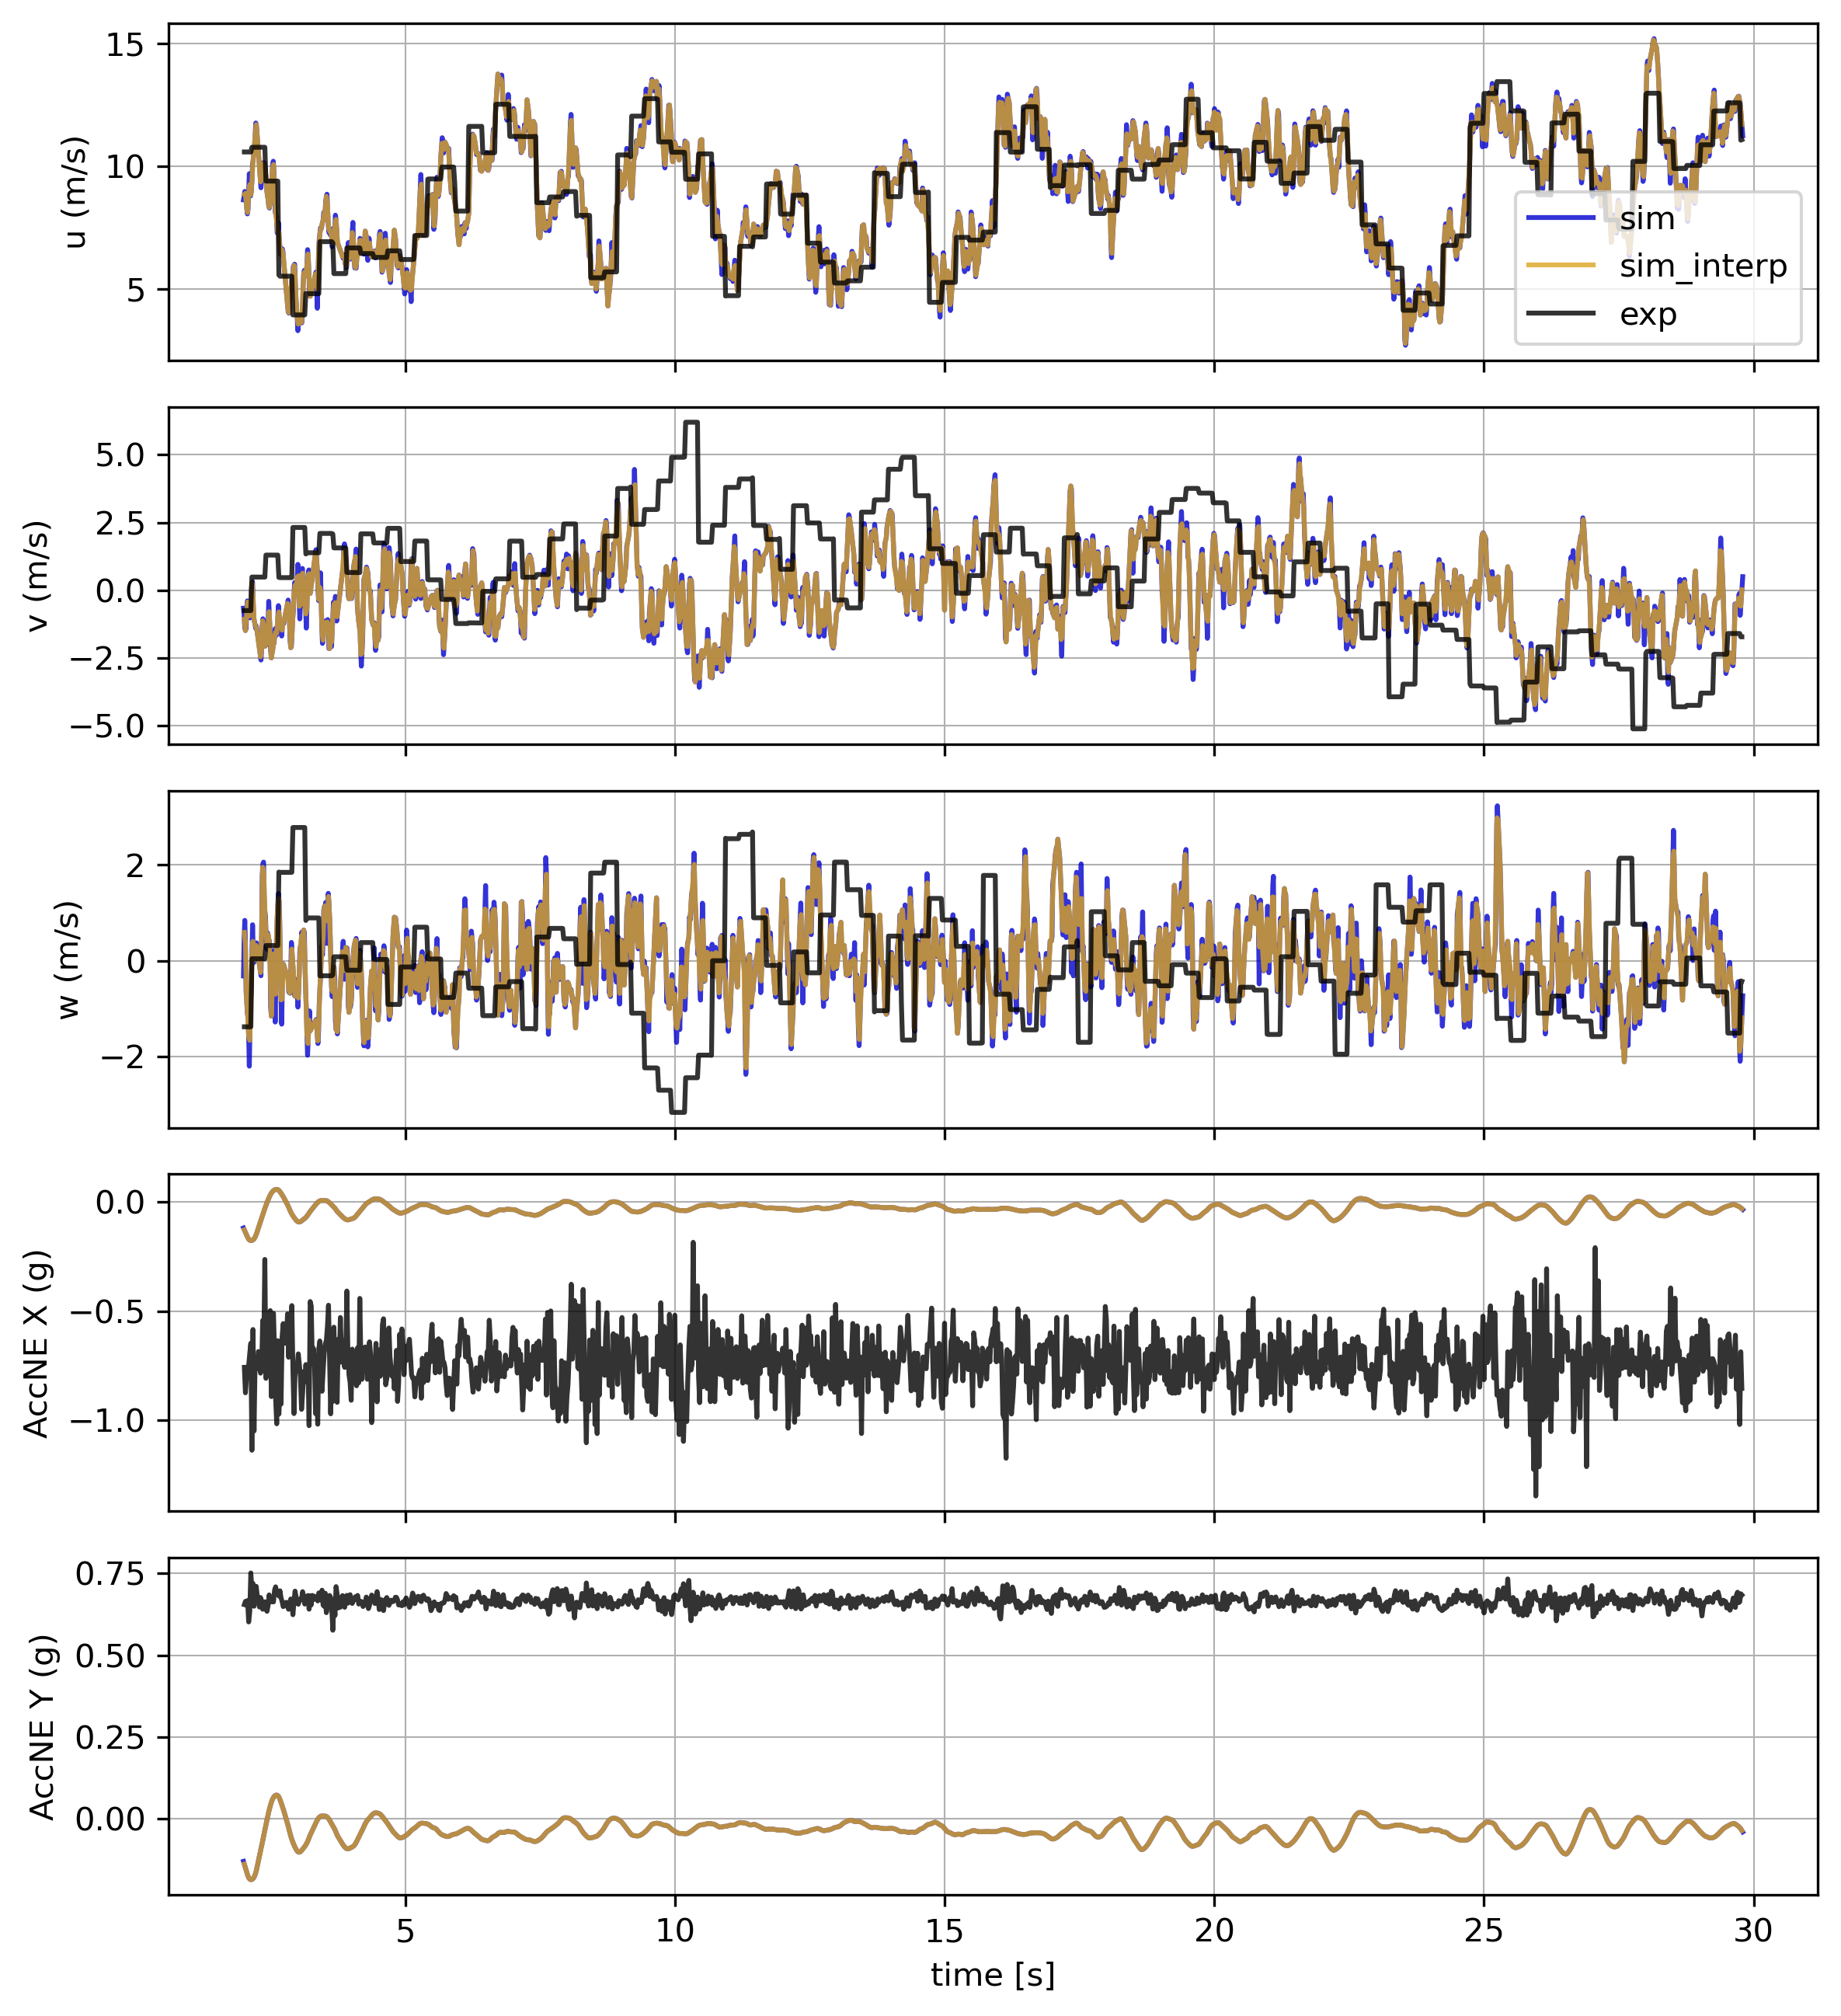

In [45]:
# plot velocity signals and accelerations
colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}

comps = ['u (m/s)','v (m/s)','w (m/s)','AccNE X (g)','AccNE Y (g)']
# vars = ['exp']
vars = ['sim','sim_interp','exp']
# vars = ['exp']

fig, axs = plt.subplots(len(comps),1, figsize=[8,len(comps)*1.75], sharex=True, dpi=300)

for comp,ax in zip(comps, axs.ravel()):
    for var in vars:
        pltdata = alldata[var][comp][alldata[var][comp].index > 2.0]
        ax.plot(pltdata, label=var, alpha=0.8, color=colors[var])
        ax.set_ylabel(f"{comp}")
    ax.grid(lw=0.5)
axs[0].legend()
axs[-1].set_xlabel("time [s]")
plt.tight_layout()

In [46]:
# compute errors
keys = ['sim_interp']
comps = ['u (m/s)','v (m/s)','w (m/s)','vel_mag (m/s)','Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
baseline = 'exp'

error_list = []
error_df = {}

mean_abs_err = {}
mean_perc_err = {}
for key in keys:
    mean_abs_err[key] = {}
    mean_perc_err[key] = {}
    for comp in comps:
        mean_abs_err[key][comp] = round(float(np.nanmean(alldata[key][comp].values - alldata[baseline][comp].values)),4)
        mean_perc_err[key][comp] = 100*round(float(np.nanmean((alldata[key][comp].values - alldata[baseline][comp].values)/alldata[baseline][comp].values)),3)

        # Append results as a dictionary to the error list
        error_list.append({
            'Variable': comp,
            'Mean_Absolute_Error': mean_abs_err[key][comp],
            'Mean_Percent_Error [%]': mean_perc_err[key][comp]
        })

    error_df[key] = pd.DataFrame(error_list).set_index('Variable')
error_df[key]

,Mean_Absolute_Error,Mean_Percent_Error [%]
Variable,,
u (m/s),0.0028,0.8
v (m/s),-0.4603,-91.6
w (m/s),0.0969,-91.8
vel_mag (m/s),-0.2468,-2.2
Drag force (kN),-0.3564,-4.8
Lift force (kN),-0.7089,-12.9
Drag Coefficient,-0.2881,-0.8
Lift Coefficient,-0.4850,-9.3


In [62]:
# compute stats
# histograms
time_threshold = 2.0

vars_for_stats = ['u (m/s)', 'v (m/s)', 'w (m/s)', 
        'Drag force (kN)', 'Lift force (kN)', 
        'Drag Coefficient', 'Lift Coefficient']
nbins = 25

statistics_list = []

for var in vars_for_stats:
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > time_threshold]
        
        stats = {
            'Key': f"{key}",
            'Var': f"{var}",
            'Mean': np.nanmean(pltdata.values),
            'Median': np.nanmedian(pltdata.values),
            'Max': np.max(pltdata.values),
            'Min': np.min(pltdata.values),
            'Std Dev': np.std(pltdata.values)
        }
        statistics_list.append(stats)

statistics_df = pd.DataFrame(statistics_list).set_index('Key')
statistics_df.round(3)

,Var,Mean,Median,Max,Min,Std Dev
Key,,,,,,
exp,u (m/s),9.017,9.481,13.455,3.946,2.392
sim,u (m/s),9.086,9.390,15.204,2.710,2.381
sim_interp,u (m/s),9.043,9.317,15.152,2.784,2.374
exp,v (m/s),0.483,0.729,6.197,-5.110,2.407
sim,v (m/s),-0.071,-0.081,4.879,-4.405,1.425
sim_interp,v (m/s),-0.040,-0.059,4.665,-4.218,1.388
exp,w (m/s),-0.131,-0.241,2.784,-3.173,1.145
sim,w (m/s),-0.013,-0.043,3.236,-2.378,0.819
sim_interp,w (m/s),-0.018,-0.061,2.986,-2.243,0.772


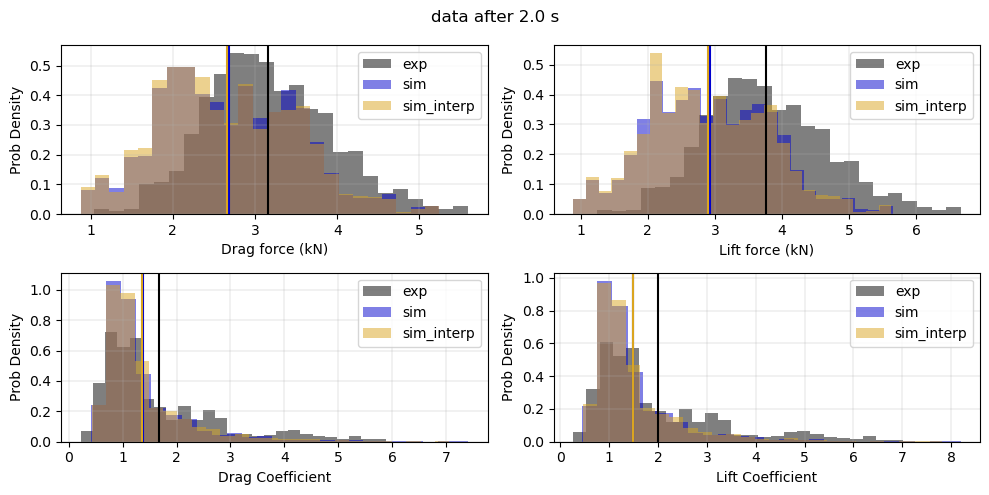

In [60]:
# histograms
time_threshold = 2.0

vars = ['Drag force (kN)', 'Lift force (kN)', 
        'Drag Coefficient', 'Lift Coefficient']
nbins = 25

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
fig, axs = plt.subplots(2,2,figsize=[10,5]) #, dpi=300) #, sharey=True)
plt.suptitle(f'data after {time_threshold} s')
# for j,u in enumerate(float_list_to_str_list(u_refs0)):

statistics_list = []

for var,ax in zip(vars, axs.ravel()):
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > time_threshold]
        
        ax.hist(pltdata, bins=nbins, density=True, alpha=0.5, label=key, color=colors[key])
        ax.axvline(np.mean(pltdata.values), color=colors[key], label='')
        ax.set_xlabel(var)
        ax.legend()

for ax in axs.ravel():
    ax.grid(lw=0.25)
    ax.legend()
    ax.set_ylabel('Prob Density')

# # for ax in axs:
# axs[-1].set_xlabel('time [s]')

plt.tight_layout()

In [ ]:
# compute flow metrics
def compute_TI(u,v,w):
    umag = (u**2 + v**2 + w**2)**0.5
    
    Iu = np.std(u, axis=0) / np.mean(umag, axis=0)
    Iv = np.std(v, axis=0) / np.mean(umag, axis=0)
    Iw = np.std(w, axis=0) / np.mean(umag, axis=0)

    return Iu, Iv, Iw

# Collect TI data for each dataset
TI_list = []  # Empty list to hold the results for the DataFrame

for key in alldata.keys():
    Iu, Iv, Iw = compute_TI(alldata[key]['u (m/s)'], alldata[key]['v (m/s)'], alldata[key]['w (m/s)'])
    
    # Append the results as a dictionary to the list
    TI_list.append({
        'Key': key,  # Use `key` to identify the dataset
        'Iu': round(Iu, 3),
        'Iv': round(Iv, 3),
        'Iw': round(Iw, 3)
    })

# Convert the list of dictionaries to a DataFrame
TI_df = pd.DataFrame(TI_list).set_index('Key')

# Print the resulting DataFrame
TI_df

In [ ]:
# Smooth high frequency region
def runningMeanFast(x, N):
    """
    Calculates the running mean of an array x over a window size N.

    Returns:
        np.ndarray: Smoothed signal
    """
    return np.convolve(x, np.ones(N)/N, mode='same') 

def compute_spectra(u, U_mean, height, fs, overlap):
    """
    Computes the normalized energy spectrum of a velocity time series `u`,
    smooths the high-frequency tail, and returns the normalized frequency
    and smoothed normalized power spectral density.

    Parameters:
        u (array-like): Time series of velocity fluctuations (1D)
        U_mean (float): Mean flow velocity (for normalization)
        height (float): Reference height (for normalization)
        fs (float): Sampling frequency [Hz]
        overlap (int): Number of samples to overlap in Welch’s method

    Returns:
        nf_U_corr (np.ndarray): Normalized frequency array
        nPxxf_mod_U_corr (list of np.ndarray): Concatenated original and smoothed
            normalized power spectral density
    """

    # Length of the input time series (used for FFT size and window)
    nblock = len(u)

    # Use a Hamming window for spectral estimation
    win = np.hamming(math.floor(nblock/10))

    # Convert u to a pandas Series for easier handling (e.g., dropna, stats)
    U_corr = pd.Series(u)
    # do I need to detrend this? - probably not bc of "detrend = constant" in welch function call

    # Standard deviation of the fluctuations (used to normalize PSD)
    u_std = U_corr.std()

    # Compute power spectral density using Welch's method
    f_U_corr, Pxxf_U_corr = welch(U_corr.dropna(), fs, window=win, noverlap=overlap, nfft=nblock, detrend='constant', return_onesided=True) # detrend constant removes mean (zero-mean segments)
    
    # Normalize frequency: non-dimensional frequency = f * z / U_mean
    nf_U_corr = f_U_corr*height/abs(U_mean)

    # Normalize power: dimensionless spectral density
    nPxxf_U_corr = (f_U_corr*Pxxf_U_corr)/u_std**2

    # Identify index where normalized frequency > 0.3 (start smoothing here)
    index_highfreq_U_corr = list(np.where([abs(nf_U_corr)>0.3]))

    # Extract the high-frequency tail to smooth
    nPxxf_smooth_U_corr = nPxxf_U_corr[index_highfreq_U_corr[0][0]:len(nPxxf_U_corr)]

    # Apply running mean to smooth the high-frequency region
    avg_window_size = int(nblock/6)
    nPxxf_smooth_U_corr = runningMeanFast(nPxxf_smooth_U_corr,avg_window_size) # 200)

    # Concatenate the low-frequency part (unsmoothed) with the smoothed tail
    # nPxxf_mod_U_corr = [nPxxf_U_corr[0:index_highfreq_U_corr[0][0]-1],nPxxf_smooth_U_corr]
    nPxxf_mod_U_corr = nPxxf_U_corr # without smoothing

    # return nf_U_corr, nPxxf_mod_U_corr
    return nf_U_corr, nPxxf_mod_U_corr

In [ ]:
# spectra of flow
fs = {'exp': 50, 'sim': 1/dt_sim, 'sim_interp': 50} # Hz
overlap = 0

vars = alldata.keys()
comps = ['u','v','w','vel_mag']

nf_corr = {}; nPxxf_mod_corr = {}
U_mean = {}

for var in vars:
    U_mean[var] = {}
    for comp in comps:
        # Compute the mean while ignoring NaN values
        U_mean[var][comp] = float(np.nanmean(alldata[var][comp+' (m/s)'].values))

for var in vars:
    nf_corr[var] = {}
    nPxxf_mod_corr[var] = {}
    for comp in comps:
        nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[var][comp+' (m/s)'].values.squeeze(), U_mean[var][comp], zloc, fs[var], overlap)
        
fig, axs = plt.subplots(1,4, figsize=[12,3]) #, sharey=True)

for var in vars:
    for comp,ax in zip(comps, axs.ravel()):
        # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
        ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
        ax.set_xlabel(f"$fz/{comp}$")
        ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")
axs[0].legend(loc='lower left',fontsize=8)
# axs[0].set_title('streamwise u spectra')
# axs[0].set_xlim(10e-3, 10e-1)
# axs[0].set_ylim(10e-3, 10e-1)
plt.tight_layout()

In [ ]:
# spectra of loads
fs = {'exp': 50, 'sim': 1/dt_sim, 'sim_interp': 50} # Hz
overlap = 0

vars = alldata.keys()
comps = ['Drag force (kN)', 'Lift force (kN)']

nf_corr = {}; nPxxf_mod_corr = {}
comp_mean = {}

for var in vars:
    comp_mean[var] = {}
    for comp in comps:
        # Compute the mean while ignoring NaN values
        comp_mean[var][comp] = float(np.nanmean(alldata[var][comp].values))

for var in vars:
    nf_corr[var] = {}
    nPxxf_mod_corr[var] = {}
    for comp in comps:
        nf_corr[var][comp], nPxxf_mod_corr[var][comp] = compute_spectra(alldata[var][comp].values.squeeze(), comp_mean[var][comp], zloc, fs[var], overlap)
        
fig, axs = plt.subplots(1,2, figsize=[7,3]) #, sharey=True)

for var in vars:
    for comp,ax in zip(comps, axs.ravel()):
        # ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp][1])]), nPxxf_mod_corr[var][comp][1], color=colors[var], label=var)       
        ax.loglog(abs(nf_corr[var][comp][0:len(nPxxf_mod_corr[var][comp])]), nPxxf_mod_corr[var][comp], color=colors[var], label=var)            
        ax.set_xlabel(f"$fz/{comp}$")
        ax.set_ylabel(f"$fS_{comp}/\sigma_{comp}$")
axs[0].legend(loc='lower left',fontsize=8)
# axs[0].set_title('streamwise u spectra')
# axs[0].set_xlim(10e-3, 10e-1)
# axs[0].set_ylim(10e-3, 10e-1)
plt.tight_layout()

In [ ]:
# # first glance at drag and lift forces
# plt.style.use('default')
# time_threshold = 2.0 #12.0 # s

# vars = ['Drag force (kN)', 'Lift force (kN)', 'Drag Coefficient', 'Lift Coefficient']
# colors = {'exp': 'k', 'sim': 'mediumblue', 'sim_interp': 'goldenrod'}
# keys = ['sim','sim_interp','exp']

# fig, axs = plt.subplots(2,2,figsize=[10,5],sharex=True) #, dpi=300) #, sharey=True)
# # plt.suptitle('u='+u+' m/s')
# # for n,var in enumerate(vars):
# for var,ax in zip(vars, axs.ravel()):
#     for key in keys:
#         pltdata = alldata[key][var][alldata[key][var].index > 2.0]
#         ax.plot(pltdata, label=key, color=colors[key])
#         ax.axvline(time_threshold, linestyle=':', color='k')
#         ax.set_ylabel(var)
#         # ax.legend()
#         # axs[0].set_xlim([15, 20])
#         # axs[0].set_ylim([0.0, 4.0])

# for ax in axs.ravel():
#     ax.grid(lw=0.25)
#     # ax.legend()

# for ax in axs[-1,:]:
#     ax.set_xlabel('time [s]')

# axs[-1,-1].legend()

# plt.tight_layout()

In [ ]:
# # plot velocity signals
# fig, axs = plt.subplots(4,1, figsize=[8,6], sharex=True)

# comps = ['u','v','w','vel_mag']
# vars = ['sim','sim_interp','exp']
# # vars = ['exp']

# for comp,ax in zip(comps, axs.ravel()):
#     for var in vars:
#         ax.plot(alldata[var][comp+' (m/s)'], label=var, alpha=0.8, color=colors[var])
#         ax.set_ylabel(f"{comp} [m/s]")
#     ax.grid(lw=0.5)
# axs[0].legend()
# axs[-1].set_xlabel("time [s]")
# plt.tight_layout()

In [ ]:
# # if needed for debugging: plot signal from h5 file and sonic
# import h5py

# turb_h5_fname = '/projects/pvopt/aps_dfd_2024/PVade/input/pct_constrained_turb_ny154_nz38_sonic1_30s_u9.0_50Hz.h5'
# sim_turb_data = {}

# with h5py.File(turb_h5_fname, "r") as fp:
#     for key, val in fp.items():
#         print(key, val.shape, val.dtype)

#     t_fp = fp["time_index"][:]
#     y_fp = fp["y_coordinates"][:]
#     z_fp = fp["z_coordinates"][:]

#     # comp="u"
#     # fig, ax = plt.subplots()
#     # plt.suptitle('pyconturb flowfield')
#     # plt.imshow(fp[comp][0, :, :],  # imshow requires nz-ny slice
#     #             origin='lower',  # smallest y-z in lower left, not upper left
#     #             extent=[y_fp[0], y_fp[-1], z_fp[0], z_fp[-1]],  # lateral and vertical limits
#     #             interpolation='bilinear',
#     #             cmap='coolwarm')  # image smoothing
#     # plt.colorbar(label=comp)

#     sim_turb_data["u"] = fp["u"][:, :, :]
#     sim_turb_data["v"] = fp["v"][:, :, :]
#     sim_turb_data["w"] = fp["w"][:, :, :]

# jp = int(np.argmin(np.abs(y_fp - yloc)))
# kp = int(np.argmin(np.abs(z_fp - zloc)))
# # print(f'comparing timeseries at (y,z) = ({y_fp[jp]:.2f},{z_fp[kp]:.2f}) to sonic loc of ({yloc:.2f},{zloc:.2f})')

# fig, axs = plt.subplots(3,1, figsize=[8,6], sharex=True)
# plt.suptitle(f'comparing timeseries at (y,z) = ({y_fp[jp]:.2f},{z_fp[kp]:.2f}) to sonic loc of ({yloc:.2f},{zloc:.2f})')
# for comp,ax in zip(['u','v','w'], axs.ravel()):
#     ax.plot(t_fp,sim_turb_data[comp][:,kp,jp], label='pyconturb')
#     ax.plot(alldata['sim'][comp+' (m/s)'], label='pvade at inlet')
#     ax.plot(alldata['exp'][comp+' (m/s)'], 'k', label='experimental')
#     ax.set_ylabel(f"{comp} [m/s]")
#     ax.grid(lw=0.5)
# axs[0].legend()
# axs[-1].set_xlabel("time [s]")
# plt.tight_layout()